# Clustering do PIB Municipal: K-Means vs K-Medoids

Identificar **grupos de municípios brasileiros com perfis econômicos semelhantes**, com base no Produto Interno Bruto (PIB), utilizando dois algoritmos de agrupamento:

## 1. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

## 2. Carregamento e Exploração Inicial dos Dados

In [2]:
df = pd.read_csv('br_ibge_pib_municipio.csv')

print('Primeiras linhas do dataset:')
print(df.head())

print('\nInformações do dataset:')
df.info()

print('\nEstatísticas descritivas:')
print(df.describe())

print('\nValores ausentes por coluna:')
print(df.isnull().sum())

print('\nAnos disponíveis:')
print(sorted(df['ano'].unique()))
print(f'Total de anos: {df["ano"].nunique()}')

Primeiras linhas do dataset:
   id_municipio   ano       pib  impostos_liquidos          va  \
0       1100403  2002  45060000          3219000.0  41841000.0   
1       1101005  2002  43979000          1689000.0  42290000.0   
2       1200336  2002  31111000           365000.0  30746000.0   
3       1200385  2002  54088000           916000.0  53172000.0   
4       1301654  2002  26050000           676000.0  25374000.0   

   va_agropecuaria  va_industria  va_servicos  va_adespss  
0        9171000.0     1992000.0    8865000.0  21813000.0  
1       12082000.0     1718000.0    4590000.0  23899000.0  
2        4954000.0     1462000.0    4100000.0  20230000.0  
3       17208000.0     2609000.0    6527000.0  26827000.0  
4        7184000.0      864000.0    2598000.0  14728000.0  

Informações do dataset:
<class 'pandas.DataFrame'>
RangeIndex: 122466 entries, 0 to 122465
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   

## 3. Pré-processamento dos Dados

Selecionamos os anos **2022 e 2023**.

In [3]:
variaveis_preferidas = ['pib', 'va_agropecuaria', 'va_industria', 'va_servicos', 'va_adespss']
anos_selecionados = [2023, 2022]

anos_ausentes = [ano for ano in anos_selecionados if ano not in df['ano'].values]
if anos_ausentes:
    raise ValueError(f'Os anos {anos_ausentes} não estão disponíveis no dataset.')

print(f'Anos selecionados: {anos_selecionados}')

df_ano = df[df['ano'].isin(anos_selecionados)].copy()
print(f'Registros nos anos selecionados: {len(df_ano)}')
print(df_ano['ano'].value_counts().sort_index())

variaveis_clustering = [
    var for var in variaveis_preferidas
    if var in df_ano.columns and df_ano[var].notna().all()
]

if not variaveis_clustering:
    raise ValueError('Nenhuma variável possui dados completos para 2022 e 2023.')

variaveis_indisponiveis = [var for var in variaveis_preferidas if var not in variaveis_clustering]
if variaveis_indisponiveis:
    print(f'\nVariáveis indisponíveis: {variaveis_indisponiveis}')
    print('Usando apenas PIB total com pivot por município.')

if set(variaveis_clustering) == {'pib'} and len(anos_selecionados) == 2:
    df_pivot = (
        df_ano.pivot(index='id_municipio', columns='ano', values='pib')
        .dropna()
        .reset_index()
    )
    df_pivot.columns = ['id_municipio'] + [f'pib_{int(ano)}' for ano in df_pivot.columns[1:]]
    variaveis_clustering = [col for col in df_pivot.columns if col != 'id_municipio']
    df_ano = df_pivot.copy()

df_clustering = df_ano[variaveis_clustering].copy()

if df_clustering.isnull().sum().sum() > 0:
    linhas_validas = df_clustering.notna().all(axis=1)
    df_clustering = df_clustering[linhas_validas].copy()
    df_ano = df_ano.loc[df_clustering.index].copy()

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_clustering),
    columns=variaveis_clustering,
    index=df_clustering.index,
)

print(f'\nMunicípios analisados: {len(df_clustering)}')
print(f'Variáveis de clustering: {variaveis_clustering}')
print('\nEstatísticas após padronização:')
print(df_scaled.describe())

Anos selecionados: [2023, 2022]
Registros nos anos selecionados: 11140
ano
2022    5570
2023    5570
Name: count, dtype: int64

Variáveis indisponíveis: ['va_agropecuaria', 'va_industria', 'va_servicos', 'va_adespss']
Usando apenas PIB total com pivot por município.

Municípios analisados: 5570
Variáveis de clustering: ['pib_2022', 'pib_2023']

Estatísticas após padronização:
           pib_2022      pib_2023
count  5.570000e+03  5.570000e+03
mean   5.102641e-18 -5.102641e-18
std    1.000090e+00  1.000090e+00
min   -1.141181e-01 -1.113622e-01
25%   -1.076910e-01 -1.050204e-01
50%   -9.796974e-02 -9.507000e-02
75%   -6.722445e-02 -6.475818e-02
max    6.023818e+01  6.114499e+01


## 4. Implementação dos Algoritmos

In [4]:
def meu_kmedoids(X, k, max_iter=100, random_state=42):
    """K-Medoids (PAM simplificado) com distância euclidiana."""
    rng = np.random.default_rng(random_state)
    X = np.asarray(X, dtype=float)
    m = X.shape[0]

    medoid_indices = rng.choice(m, size=k, replace=False)
    labels = np.zeros(m, dtype=int)

    for _ in range(max_iter):
        medoids = X[medoid_indices]
        distancias = np.linalg.norm(X[:, np.newaxis, :] - medoids, axis=2)
        labels = np.argmin(distancias, axis=1)

        novos_medoid_indices = np.zeros(k, dtype=int)
        for i in range(k):
            indices_cluster = np.where(labels == i)[0]
            if len(indices_cluster) == 0:
                novos_medoid_indices[i] = medoid_indices[i]
                continue

            pontos = X[indices_cluster]
            dist_interna = np.linalg.norm(
                pontos[:, np.newaxis, :] - pontos, axis=2
            )
            melhor = indices_cluster[np.argmin(dist_interna.sum(axis=1))]
            novos_medoid_indices[i] = melhor

        if np.array_equal(medoid_indices, novos_medoid_indices):
            break
        medoid_indices = novos_medoid_indices

    return medoid_indices, labels


def custo_kmedoids(X, labels, medoid_indices):
    """Soma das distâncias de cada ponto ao medoide do seu cluster."""
    medoids = X[medoid_indices]
    distancias = np.linalg.norm(X[:, np.newaxis, :] - medoids, axis=2)
    return distancias[np.arange(len(labels)), labels].sum()

## 5. Determinação do Número Ótimo de Clusters (k)

Avaliamos **k de 2 a 10** para ambos os algoritmos:

In [5]:
k_range = range(2, 11)
X_array = df_scaled.values

inercias, custos = [], []
sil_kmeans_list, sil_kmedoids_list = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_km = km.fit_predict(df_scaled)
    inercias.append(km.inertia_)
    sil_kmeans_list.append(silhouette_score(df_scaled, labels_km))

    med_idx, labels_md = meu_kmedoids(X_array, k=k, random_state=42)
    custos.append(custo_kmedoids(X_array, labels_md, med_idx))
    sil_kmedoids_list.append(silhouette_score(df_scaled, labels_md))

    print(
        f'k={k} | K-Means: inércia={inercias[-1]:.2f}, sil={sil_kmeans_list[-1]:.4f} | '
        f'K-Medoids: custo={custos[-1]:.2f}, sil={sil_kmedoids_list[-1]:.4f}'
    )

k=2 | K-Means: inércia=3701.76, sil=0.9950 | K-Medoids: custo=642.68, sil=0.9238
k=3 | K-Means: inércia=1751.92, sil=0.9925 | K-Medoids: custo=534.47, sil=0.7954
k=4 | K-Means: inércia=582.53, sil=0.9685 | K-Medoids: custo=469.59, sil=0.7230
k=5 | K-Means: inércia=277.78, sil=0.9293 | K-Medoids: custo=381.69, sil=0.6834
k=6 | K-Means: inércia=174.76, sil=0.9158 | K-Medoids: custo=345.85, sil=0.6612
k=7 | K-Means: inércia=117.18, sil=0.8705 | K-Medoids: custo=323.21, sil=0.5676
k=8 | K-Means: inércia=83.27, sil=0.8540 | K-Medoids: custo=307.52, sil=0.5562
k=9 | K-Means: inércia=64.51, sil=0.8160 | K-Medoids: custo=292.95, sil=0.5552
k=10 | K-Means: inércia=54.41, sil=0.8142 | K-Medoids: custo=285.62, sil=0.5340


In [6]:
def encontrar_cotovelo(k_vals, valores):
    """Detecta o cotovelo pela maior distância à reta entre extremos."""
    k_arr = np.array(k_vals, dtype=float)
    y = np.array(valores, dtype=float)
    x1, y1 = k_arr[0], y[0]
    x2, y2 = k_arr[-1], y[-1]
    distancias = np.abs((y2 - y1) * k_arr - (x2 - x1) * y + x2 * y1 - y2 * x1)
    distancias /= np.sqrt((y2 - y1) ** 2 + (x2 - x1) ** 2)
    return int(k_arr[np.argmax(distancias)])


k_list = list(k_range)
k_elbow = encontrar_cotovelo(k_list, inercias)
k_sil_kmeans = k_list[int(np.argmax(sil_kmeans_list))]
k_sil_kmedoids = k_list[int(np.argmax(sil_kmedoids_list))]
sil_media = [(a + b) / 2 for a, b in zip(sil_kmeans_list, sil_kmedoids_list)]
k_sil_medio = k_list[int(np.argmax(sil_media))]

k_otimo = k_sil_medio

print('Sugestões de k por critério:')
print(f'  - Cotovelo (inércia K-Means): k = {k_elbow}')
print(f'  - Silhouette K-Means:         k = {k_sil_kmeans} (score = {max(sil_kmeans_list):.4f})')
print(f'  - Silhouette K-Medoids:       k = {k_sil_kmedoids} (score = {max(sil_kmedoids_list):.4f})')
print(f'  - Silhouette médio:           k = {k_sil_medio} (score = {max(sil_media):.4f})')
print(f'\nNúmero de clusters adotado: k = {k_otimo}')

Sugestões de k por critério:
  - Cotovelo (inércia K-Means): k = 4
  - Silhouette K-Means:         k = 2 (score = 0.9950)
  - Silhouette K-Medoids:       k = 2 (score = 0.9238)
  - Silhouette médio:           k = 2 (score = 0.9594)

Número de clusters adotado: k = 2


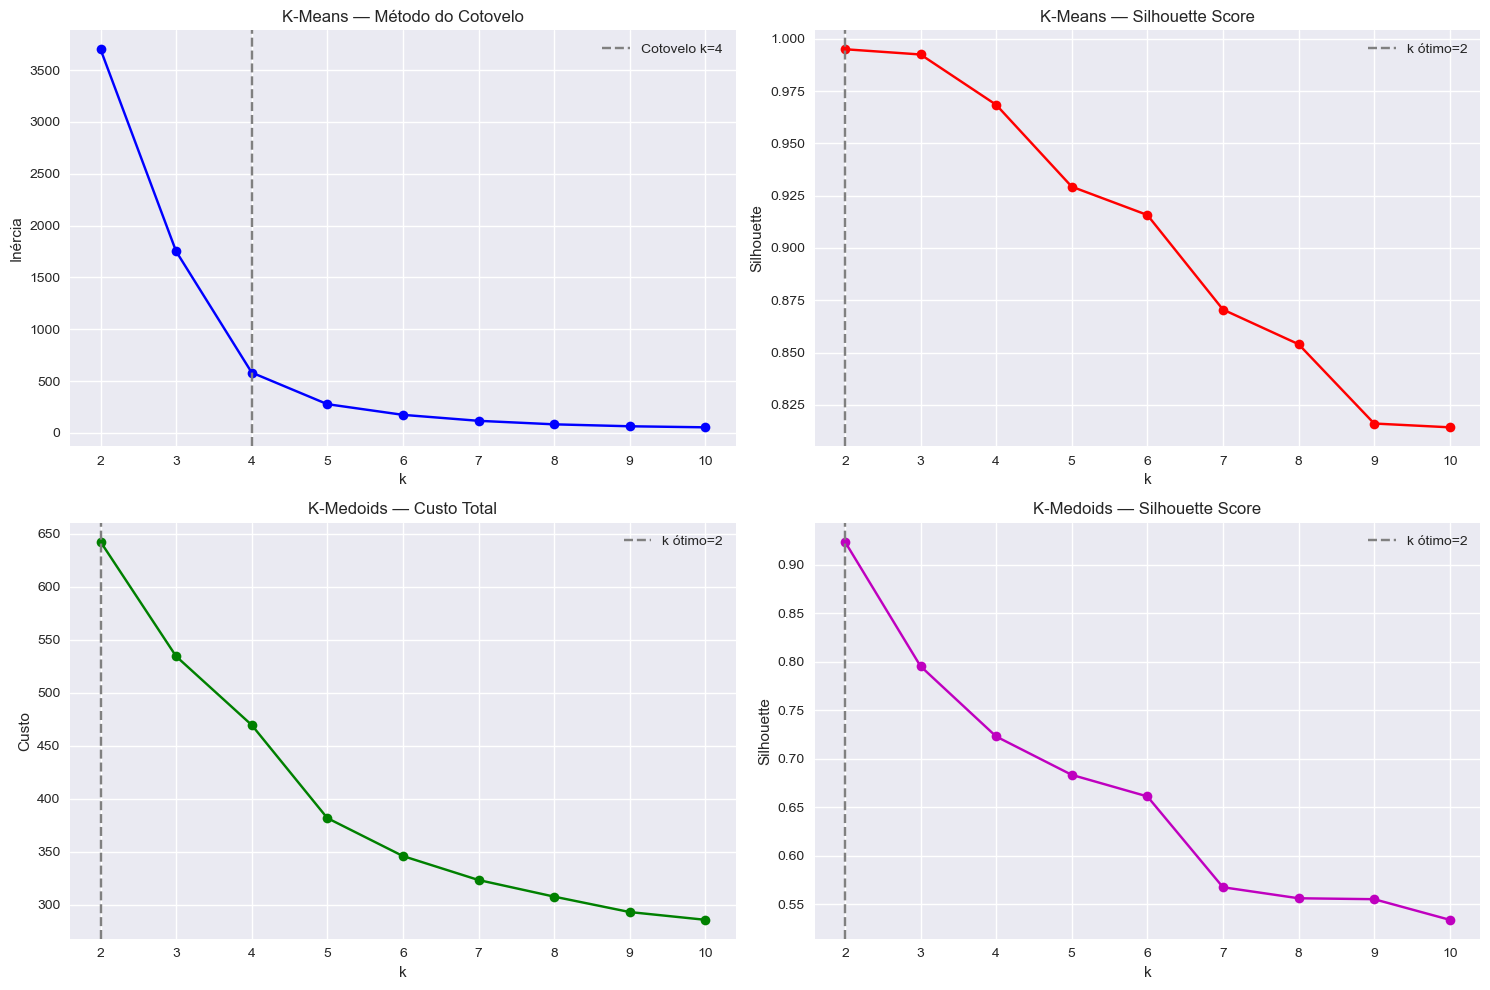

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(k_range, inercias, 'bo-')
axes[0, 0].axvline(k_elbow, color='gray', linestyle='--', label=f'Cotovelo k={k_elbow}')
axes[0, 0].set_title('K-Means — Método do Cotovelo')
axes[0, 0].set_xlabel('k')
axes[0, 0].set_ylabel('Inércia')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(k_range, sil_kmeans_list, 'ro-')
axes[0, 1].axvline(k_otimo, color='gray', linestyle='--', label=f'k ótimo={k_otimo}')
axes[0, 1].set_title('K-Means — Silhouette Score')
axes[0, 1].set_xlabel('k')
axes[0, 1].set_ylabel('Silhouette')
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(k_range, custos, 'go-')
axes[1, 0].axvline(k_otimo, color='gray', linestyle='--', label=f'k ótimo={k_otimo}')
axes[1, 0].set_title('K-Medoids — Custo Total')
axes[1, 0].set_xlabel('k')
axes[1, 0].set_ylabel('Custo')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(k_range, sil_kmedoids_list, 'mo-')
axes[1, 1].axvline(k_otimo, color='gray', linestyle='--', label=f'k ótimo={k_otimo}')
axes[1, 1].set_title('K-Medoids — Silhouette Score')
axes[1, 1].set_xlabel('k')
axes[1, 1].set_ylabel('Silhouette')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

## 6. Aplicação e Análise — K-Means

In [8]:
kmeans_final = KMeans(n_clusters=k_otimo, random_state=42, n_init=10)
labels_kmeans = kmeans_final.fit_predict(df_scaled)

df_kmeans = df_clustering.copy()
df_kmeans['cluster'] = labels_kmeans

print('K-Means aplicado com sucesso!')
print(f'Inércia final: {kmeans_final.inertia_:.2f}')
print(f'Silhouette Score: {silhouette_score(df_scaled, labels_kmeans):.4f}')
print('\nDistribuição de municípios por cluster:')
print(df_kmeans['cluster'].value_counts().sort_index())

medias_kmeans = df_kmeans.groupby('cluster')[variaveis_clustering].mean()
print('\nMédias por cluster (valores originais):')
print(medias_kmeans)

K-Means aplicado com sucesso!
Inércia final: 3701.76
Silhouette Score: 0.9950

Distribuição de municípios por cluster:
cluster
0       3
1    5567
Name: count, dtype: int64

Médias por cluster (valores originais):
             pib_2022      pib_2023
cluster                            
0        5.517059e+11  6.169855e+11
1        1.513303e+09  1.633265e+09


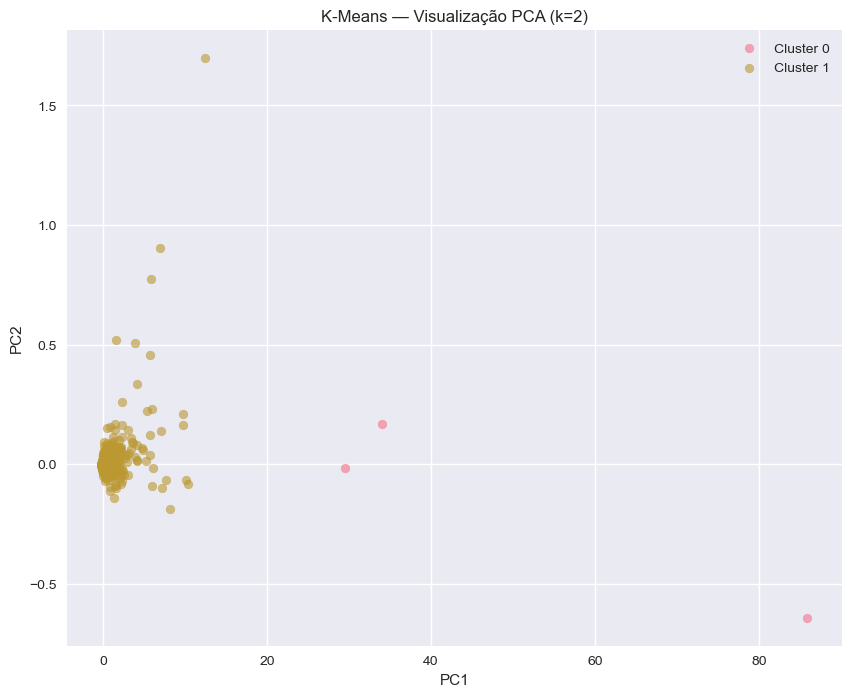

In [9]:
n_componentes = min(2, df_scaled.shape[1])
pca = PCA(n_components=n_componentes)
coords = pca.fit_transform(df_scaled)

plt.figure(figsize=(10, 8))
for cluster in sorted(df_kmeans['cluster'].unique()):
    mask = labels_kmeans == cluster
    plt.scatter(coords[mask, 0], coords[mask, 1], label=f'Cluster {cluster}', alpha=0.6, s=40)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'K-Means — Visualização PCA (k={k_otimo})')
plt.legend()
plt.grid(True)
plt.show()

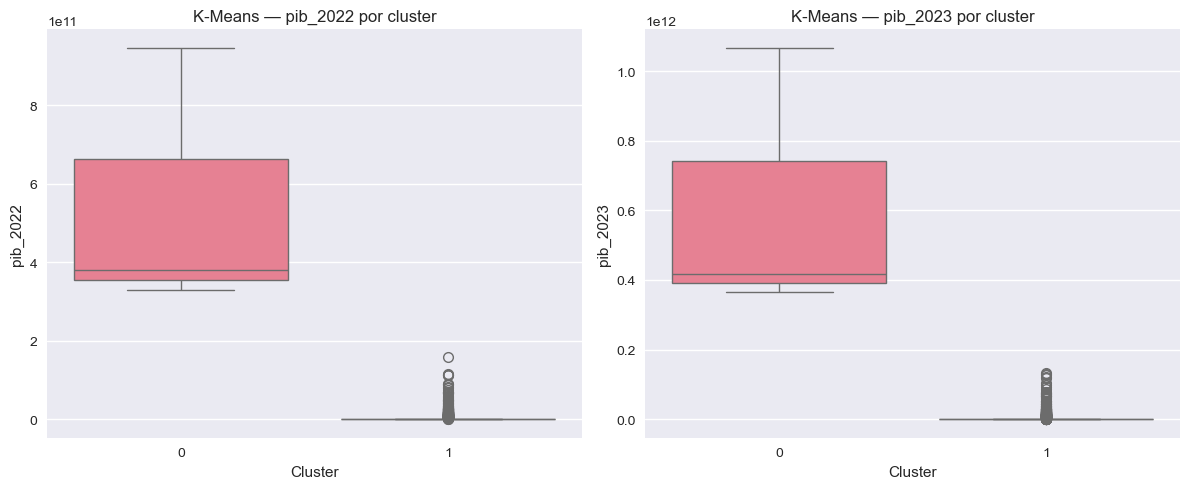

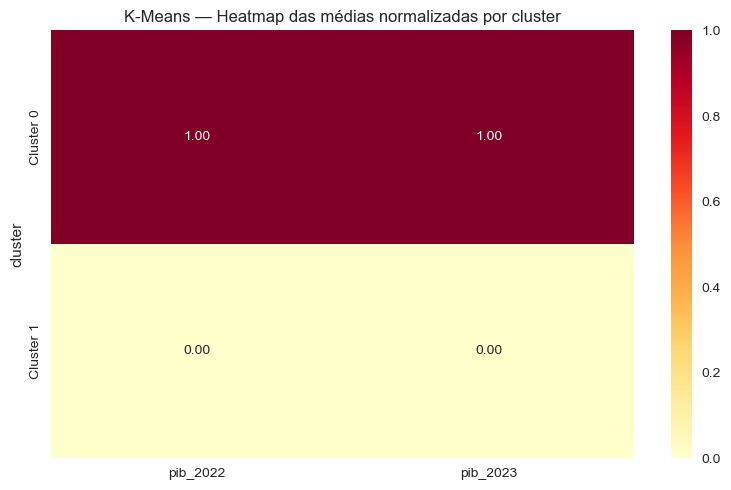

In [10]:
fig, axes = plt.subplots(1, len(variaveis_clustering), figsize=(6 * len(variaveis_clustering), 5))
if len(variaveis_clustering) == 1:
    axes = [axes]

for ax, var in zip(axes, variaveis_clustering):
    sns.boxplot(data=df_kmeans, x='cluster', y=var, ax=ax)
    ax.set_title(f'K-Means — {var} por cluster')
    ax.set_xlabel('Cluster')

plt.tight_layout()
plt.show()

medias_norm = (medias_kmeans - medias_kmeans.min()) / (medias_kmeans.max() - medias_kmeans.min())
plt.figure(figsize=(8, 5))
sns.heatmap(
    medias_norm, annot=True, cmap='YlOrRd', fmt='.2f',
    xticklabels=variaveis_clustering,
    yticklabels=[f'Cluster {i}' for i in range(k_otimo)],
)
plt.title('K-Means — Heatmap das médias normalizadas por cluster')
plt.tight_layout()
plt.show()

In [11]:
print('Interpretação dos clusters — K-Means')
print('=' * 50)
for cluster in sorted(medias_kmeans.index):
    n = len(df_kmeans[df_kmeans['cluster'] == cluster])
    print(f'\nCluster {cluster} ({n} municípios):')
    for var in variaveis_clustering:
        print(f'  - {var} médio: R$ {medias_kmeans.loc[cluster, var]:,.2f}')

Interpretação dos clusters — K-Means

Cluster 0 (3 municípios):
  - pib_2022 médio: R$ 551,705,853,666.67
  - pib_2023 médio: R$ 616,985,524,333.33

Cluster 1 (5567 municípios):
  - pib_2022 médio: R$ 1,513,303,182.32
  - pib_2023 médio: R$ 1,633,265,465.24


## 7. Aplicação e Análise — K-Medoids

In [12]:
medoid_indices, labels_kmedoids = meu_kmedoids(X_array, k=k_otimo, random_state=42)
custo_final = custo_kmedoids(X_array, labels_kmedoids, medoid_indices)

df_kmedoids = df_clustering.copy()
df_kmedoids['cluster'] = labels_kmedoids

print('K-Medoids aplicado com sucesso!')
print(f'Custo final: {custo_final:.2f}')
print(f'Silhouette Score: {silhouette_score(df_scaled, labels_kmedoids):.4f}')
print('\nDistribuição de municípios por cluster:')
print(df_kmedoids['cluster'].value_counts().sort_index())

medias_kmedoids = df_kmedoids.groupby('cluster')[variaveis_clustering].mean()
print('\nMédias por cluster (valores originais):')
print(medias_kmedoids)

print('\nMedoides (municípios representativos — observações reais):')
medoides_df = df_ano.iloc[medoid_indices][['id_municipio'] + variaveis_clustering].copy()
medoides_df['cluster'] = labels_kmedoids[medoid_indices]
print(medoides_df)

K-Medoids aplicado com sucesso!
Custo final: 642.68
Silhouette Score: 0.9238

Distribuição de municípios por cluster:
cluster
0     211
1    5359
Name: count, dtype: int64

Médias por cluster (valores originais):
             pib_2022      pib_2023
cluster                            
0        3.107536e+10  3.351702e+10
1        6.573569e+08  7.223835e+08

Medoides (municípios representativos — observações reais):
      id_municipio     pib_2022     pib_2023  cluster
1495       2602902  14474714000  15897620000        0
4859       4312252    257253000    291061000        1


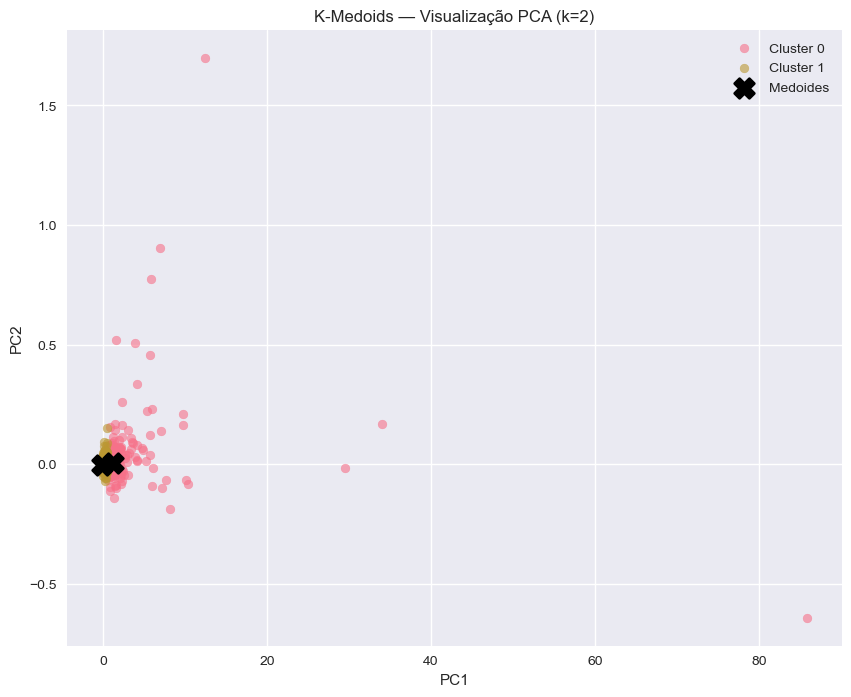

In [13]:
plt.figure(figsize=(10, 8))
for cluster in sorted(df_kmedoids['cluster'].unique()):
    mask = labels_kmedoids == cluster
    plt.scatter(coords[mask, 0], coords[mask, 1], label=f'Cluster {cluster}', alpha=0.6, s=40)

medoid_coords = coords[medoid_indices]
plt.scatter(
    medoid_coords[:, 0], medoid_coords[:, 1],
    c='black', marker='X', s=200, linewidths=2,
    label='Medoides', zorder=5,
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'K-Medoids — Visualização PCA (k={k_otimo})')
plt.legend()
plt.grid(True)
plt.show()

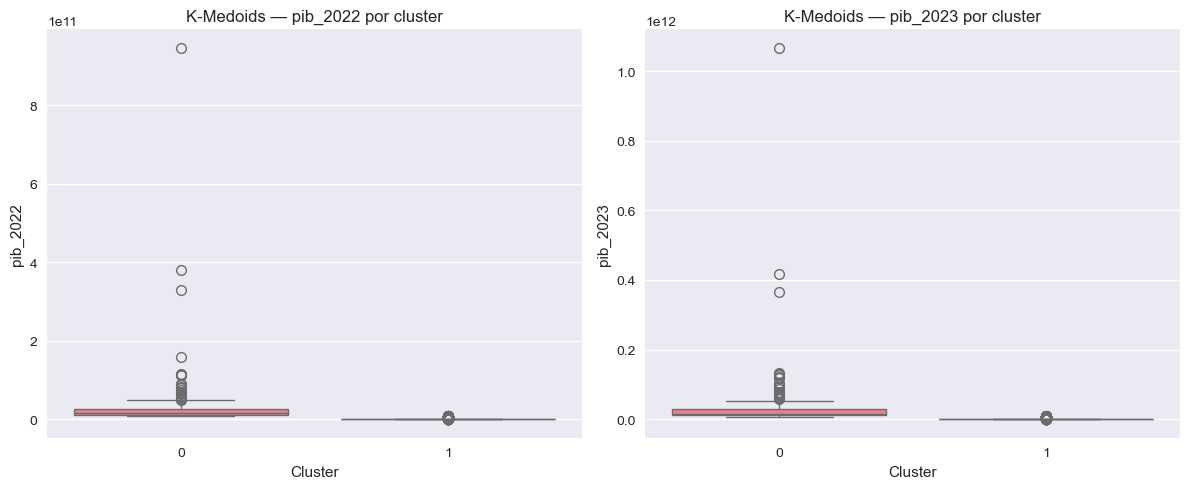

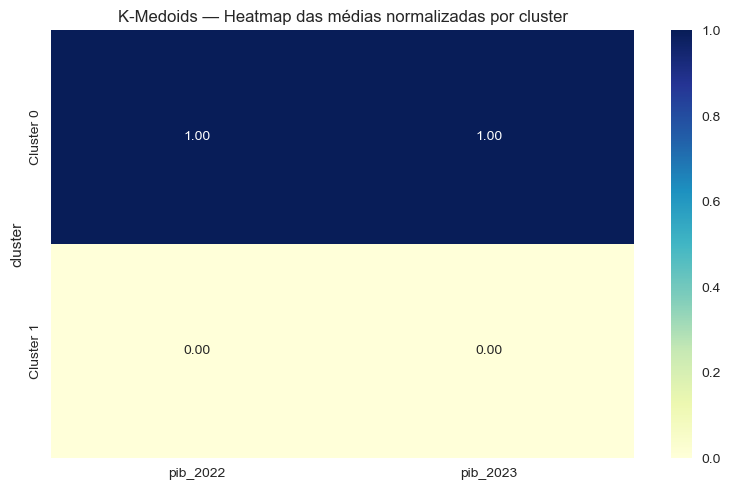

In [14]:
fig, axes = plt.subplots(1, len(variaveis_clustering), figsize=(6 * len(variaveis_clustering), 5))
if len(variaveis_clustering) == 1:
    axes = [axes]

for ax, var in zip(axes, variaveis_clustering):
    sns.boxplot(data=df_kmedoids, x='cluster', y=var, ax=ax)
    ax.set_title(f'K-Medoids — {var} por cluster')
    ax.set_xlabel('Cluster')

plt.tight_layout()
plt.show()

medias_norm_md = (medias_kmedoids - medias_kmedoids.min()) / (medias_kmedoids.max() - medias_kmedoids.min())
plt.figure(figsize=(8, 5))
sns.heatmap(
    medias_norm_md, annot=True, cmap='YlGnBu', fmt='.2f',
    xticklabels=variaveis_clustering,
    yticklabels=[f'Cluster {i}' for i in range(k_otimo)],
)
plt.title('K-Medoids — Heatmap das médias normalizadas por cluster')
plt.tight_layout()
plt.show()

In [15]:
print('Interpretação dos clusters — K-Medoids')
print('=' * 50)
for cluster in sorted(medias_kmedoids.index):
    n = len(df_kmedoids[df_kmedoids['cluster'] == cluster])
    print(f'\nCluster {cluster} ({n} municípios):')
    for var in variaveis_clustering:
        print(f'  - {var} médio: R$ {medias_kmedoids.loc[cluster, var]:,.2f}')

Interpretação dos clusters — K-Medoids

Cluster 0 (211 municípios):
  - pib_2022 médio: R$ 31,075,359,933.65
  - pib_2023 médio: R$ 33,517,024,815.17

Cluster 1 (5359 municípios):
  - pib_2022 médio: R$ 657,356,863.41
  - pib_2023 médio: R$ 722,383,501.03


## 8. Análise Comparativa

In [16]:
sil_kmeans = silhouette_score(df_scaled, labels_kmeans)
sil_kmedoids = silhouette_score(df_scaled, labels_kmedoids)
ari = adjusted_rand_score(labels_kmeans, labels_kmedoids)

comparacao = pd.DataFrame({
    'Métrica': ['Silhouette Score', 'Função objetivo', 'Adjusted Rand Index'],
    'K-Means': [
        f'{sil_kmeans:.4f}',
        f'Inércia: {kmeans_final.inertia_:.2f}',
        '—',
    ],
    'K-Medoids': [
        f'{sil_kmedoids:.4f}',
        f'Custo: {custo_final:.2f}',
        f'{ari:.4f} (vs K-Means)',
    ],
})

print(f'Tabela comparativa (k = {k_otimo}):')
print(comparacao.to_string(index=False))

print('\nDistribuição por algoritmo:')
print('K-Means:\n', pd.Series(labels_kmeans).value_counts().sort_index())
print('\nK-Medoids:\n', pd.Series(labels_kmedoids).value_counts().sort_index())

Tabela comparativa (k = 2):
            Métrica          K-Means           K-Medoids
   Silhouette Score           0.9950              0.9238
    Função objetivo Inércia: 3701.76       Custo: 642.68
Adjusted Rand Index                — 0.0260 (vs K-Means)

Distribuição por algoritmo:
K-Means:
 0       3
1    5567
Name: count, dtype: int64

K-Medoids:
 0     211
1    5359
Name: count, dtype: int64


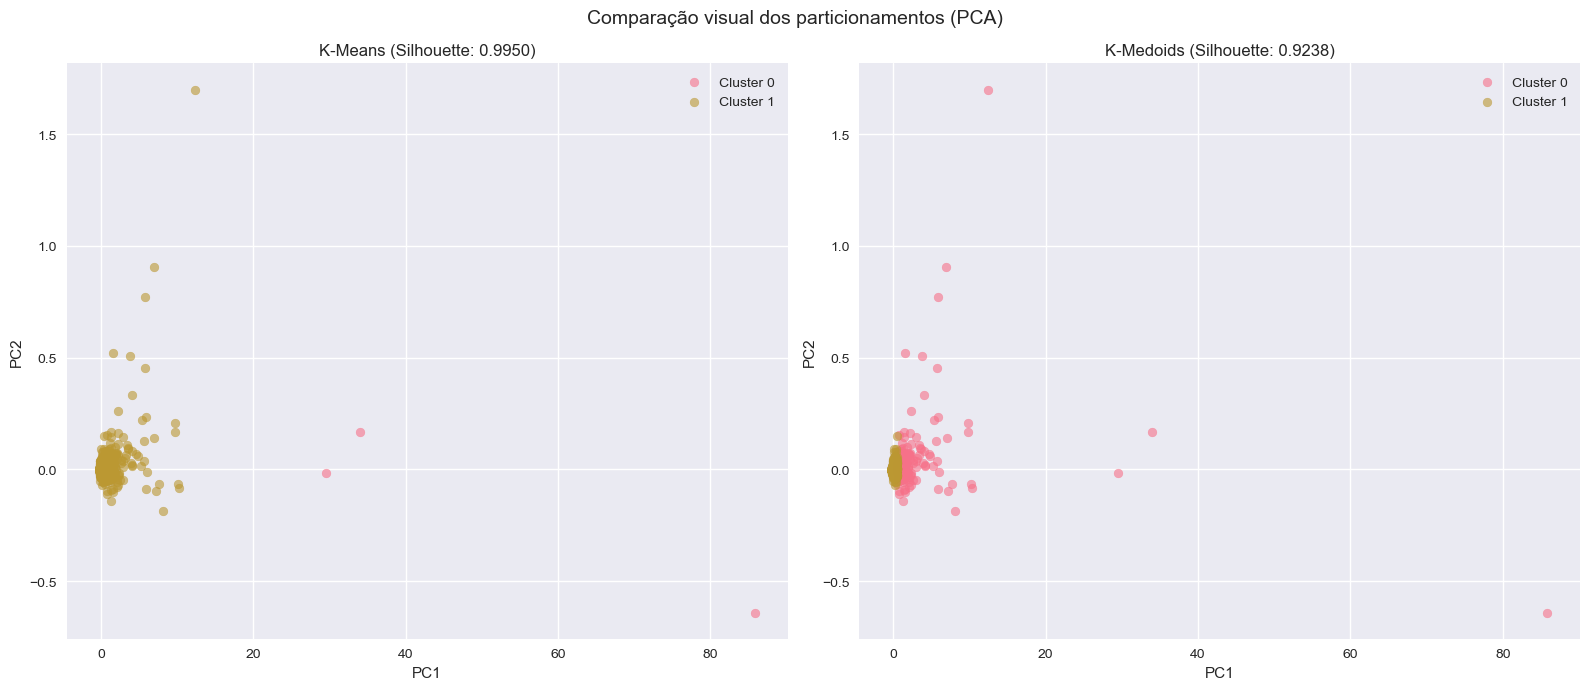

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, labels, titulo in zip(
    axes,
    [labels_kmeans, labels_kmedoids],
    ['K-Means', 'K-Medoids'],
):
    for cluster in sorted(np.unique(labels)):
        mask = labels == cluster
        ax.scatter(coords[mask, 0], coords[mask, 1], label=f'Cluster {cluster}', alpha=0.6, s=40)
    ax.set_title(f'{titulo} (Silhouette: {silhouette_score(df_scaled, labels):.4f})')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend()
    ax.grid(True)

plt.suptitle('Comparação visual dos particionamentos (PCA)', fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
df_comparacao = df_ano[['id_municipio'] + variaveis_clustering].copy()
df_comparacao['cluster_kmeans'] = labels_kmeans
df_comparacao['cluster_kmedoids'] = labels_kmedoids
df_comparacao['concordam'] = df_comparacao['cluster_kmeans'] == df_comparacao['cluster_kmedoids']

pct = df_comparacao['concordam'].mean() * 100
print(f'Municípios com o mesmo rótulo nos dois métodos: {pct:.1f}%')

print('\nMedoides K-Medoids (centros reais):')
print(df_ano.iloc[medoid_indices][['id_municipio'] + variaveis_clustering])

print('\nCentroides K-Means (médias — podem não corresponder a municípios reais):')
centroides = pd.DataFrame(kmeans_final.cluster_centers_, columns=variaveis_clustering)
centroides.index.name = 'cluster'
print(centroides)

print('\nCentroides K-Means reescalonados para escala original:')
centroides_orig = pd.DataFrame(
    scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=variaveis_clustering,
)
centroides_orig.index.name = 'cluster'
print(centroides_orig)

Municípios com o mesmo rótulo nos dois métodos: 96.3%

Medoides K-Medoids (centros reais):
      id_municipio     pib_2022     pib_2023
1495       2602902  14474714000  15897620000
4859       4312252    257253000    291061000

Centroides K-Means (médias — podem não corresponder a municípios reais):
          pib_2022   pib_2023
cluster                      
0        35.084686  35.314901
1        -0.018907  -0.019031

Centroides K-Means reescalonados para escala original:
             pib_2022      pib_2023
cluster                            
0        5.517059e+11  6.169855e+11
1        1.513303e+09  1.633265e+09
